## Benchmarking RSM, GP, ANN Modeling Approaches for Design of Experiments
Systematic benchmarking of three complementary modeling approaches — classical Response Surface Methodology (RSM), Gaussian Process (GP) surrogates, and H2O Deep Learning (ANN) — acrossDesign of Experiments datasets for BBD, CCD, DSD, Taguchi, CCFD.


In [ ]:
# Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})
from scipy import stats
from itertools import combinations
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

model_order = ['RSM', 'GP', 'ANN', 'Ensemble']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

In [2]:
met_df = pd.read_excel('Metrics.xlsx')
met_df

,DESIGN_TYPE,SCALING_METHOD,RESPONSE,NUM_FACTORS,TRAIN_SIZE,TEST_SIZE,MODEL,MASE,MAPE,TOPOLOGY,EPOCHS,KERNEL_FUNCTION,ACTIVATION_FUNCTION
0,BBD,CODED,t,3,17,5,RSM,0.162265,3.411621,NaN,NaN,NaN,NaN
1,BBD,STANDARDIZED,t,3,17,5,GP,0.427613,8.990564,NaN,NaN,Gaussian,NaN
2,BBD,STANDARDIZED,t,3,17,5,ANN,0.658158,13.837769,40-20-10,10.0,NaN,Rectifier
3,BBD,RSM:CODED; GP/ANN:STANDARDIZED,t,3,17,5,Ensemble,0.301097,6.330560,40-20-10,10.0,Gaussian,Rectifier
4,BBD,CODED,KGM,3,17,5,RSM,0.002098,0.014629,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,DSD,RSM:CODED; GP/ANN:STANDARDIZED,ErP,6,14,11,Ensemble,0.373193,44.345203,30-15,10.0,Gaussian,Rectifier
296,DSD,CODED,ErA,6,14,5,RSM,0.119703,6.413555,NaN,NaN,NaN,NaN
297,DSD,STANDARDIZED,ErA,6,14,5,GP,0.464391,22.883610,NaN,NaN,Gaussian,NaN
298,DSD,STANDARDIZED,ErA,6,14,5,ANN,0.480583,24.835505,40-20-10,10.0,NaN,Rectifier


In [4]:
# ── 1. Summary statistics by MODEL ──────────────────────────────────
summary = met_df.groupby('MODEL')[['MASE','MAPE']].agg(['mean','median','std','min','max','count'])
print("=== Summary Statistics by MODEL ===")
print(summary.to_string())

=== Summary Statistics by MODEL ===
                  MASE                                                                      MAPE                                                           
                  mean    median            std           min           max count           mean     median           std           min           max count
MODEL                                                                                                                                                      
ANN           2.383222  0.582913       7.409247  6.465610e-02  5.262348e+01    69      45.170542  12.674794  1.397839e+02  7.747459e-02  1.108167e+03    75
Ensemble      0.693616  0.315505       1.612006  2.280833e-15  1.305515e+01    69      13.699834   6.303722  2.214175e+01  3.658802e-14  1.270660e+02    75
GP            0.813202  0.450244       1.694249  3.240942e-04  1.312581e+01    74      16.685940   7.825962  2.366024e+01  1.287598e-02  1.147102e+02    74
RSM       36781.419378  0.38

In [5]:
# ── 2. Pairwise Wilcoxon rank-sum tests ─────────────────────────────
models = model_order
print("\n=== Pairwise Wilcoxon Rank-Sum Tests ===")
pw_results = {}
for metric in ['MASE', 'MAPE']:
    print(f"\n--- {metric} ---")
    pw_results[metric] = {}
    for m1, m2 in combinations(models, 2):
        g1 = met_df.loc[met_df['MODEL'] == m1, metric].dropna()
        g2 = met_df.loc[met_df['MODEL'] == m2, metric].dropna()
        stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p={pval:.4e}  {sig}")
        pw_results[metric][(m1, m2)] = pval


=== Pairwise Wilcoxon Rank-Sum Tests ===

--- MASE ---
         RSM vs GP          U=    2609.0  p=8.2259e-01  ns
         RSM vs ANN         U=    2032.0  p=1.3837e-01  ns
         RSM vs Ensemble    U=    2688.0  p=1.9111e-01  ns
          GP vs ANN         U=    2026.0  p=3.3420e-02  *
          GP vs Ensemble    U=    2911.0  p=1.4867e-01  ns
         ANN vs Ensemble    U=    3188.0  p=5.8943e-04  ***

--- MAPE ---
         RSM vs GP          U=    2773.0  p=9.9546e-01  ns
         RSM vs ANN         U=    2384.0  p=1.0767e-01  ns
         RSM vs Ensemble    U=    3123.0  p=2.4393e-01  ns
          GP vs ANN         U=    2219.0  p=3.4942e-02  *
          GP vs Ensemble    U=    3163.0  p=1.4124e-01  ns
         ANN vs Ensemble    U=    3749.0  p=4.3454e-04  ***


In [8]:
# ── ANOVA & Kruskal-Wallis: RSM vs GP vs ANN vs Ensemble ────────────
from scipy.stats import f_oneway, kruskal, levene, shapiro

for metric in ['MASE', 'MAPE']:
    groups = [met_df.loc[met_df['MODEL'] == m, metric].dropna().values for m in model_order]

    print(f"\n{'='*60}")
    print(f"  {metric}")
    print(f"{'='*60}")

    # ── Assumption checks ───────────────────────────────────────
    # Shapiro-Wilk normality test per group
    print("\nShapiro-Wilk normality test:")
    for m, g in zip(model_order, groups):
        if len(g) >= 3:
            w, p = shapiro(g)
            print(f"  {m:>10s}:  W={w:.4f}  p={p:.4e}  {'normal' if p > 0.05 else 'non-normal'}")

    # Levene's test for homogeneity of variances
    lev_stat, lev_p = levene(*groups)
    print(f"\nLevene's test (equal variances):  stat={lev_stat:.4f}  p={lev_p:.4e}  "
          f"{'equal' if lev_p > 0.05 else 'unequal'}")

    # ── One-way ANOVA ───────────────────────────────────────────
    f_stat, anova_p = f_oneway(*groups)
    print(f"\nOne-way ANOVA:  F={f_stat:.4f}  p={anova_p:.4e}  "
          f"{'***' if anova_p < 0.001 else '**' if anova_p < 0.01 else '*' if anova_p < 0.05 else 'ns'}")

    # ── Kruskal-Wallis (non-parametric alternative) ─────────────
    h_stat, kw_p = kruskal(*groups)
    print(f"Kruskal-Wallis: H={h_stat:.4f}  p={kw_p:.4e}  "
          f"{'***' if kw_p < 0.001 else '**' if kw_p < 0.01 else '*' if kw_p < 0.05 else 'ns'}")

    # ── Post-hoc Dunn's test (if Kruskal-Wallis significant) ────
    if kw_p < 0.05:
        try:
            import scikit_posthocs as sp
            dunn = sp.posthoc_dunn(met_df, val_col=metric, group_col='MODEL', p_adjust='bonferroni')
            print(f"\nDunn's post-hoc test (Bonferroni-adjusted p-values):")
            print(dunn.to_string())
        except ImportError:
            print("\n  (Install scikit-posthocs for Dunn's post-hoc test: pip install scikit-posthocs)")
            # Fallback: pairwise Mann-Whitney with Bonferroni correction
            from itertools import combinations
            n_comp = len(list(combinations(model_order, 2)))
            print(f"\n  Pairwise Mann-Whitney U with Bonferroni correction ({n_comp} comparisons):")
            for m1, m2 in combinations(model_order, 2):
                g1 = met_df.loc[met_df['MODEL'] == m1, metric].dropna()
                g2 = met_df.loc[met_df['MODEL'] == m2, metric].dropna()
                stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                adj_p = min(pval * n_comp, 1.0)
                sig = '***' if adj_p < 0.001 else '**' if adj_p < 0.01 else '*' if adj_p < 0.05 else 'ns'
                print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p_adj={adj_p:.4e}  {sig}")


  MASE

Shapiro-Wilk normality test:
         RSM:  W=0.1061  p=1.9315e-18  non-normal
          GP:  W=0.3585  p=2.3756e-16  non-normal
         ANN:  W=0.2965  p=1.6415e-16  non-normal
    Ensemble:  W=0.3212  p=3.1174e-16  non-normal

Levene's test (equal variances):  stat=1.1222  p=3.4041e-01  equal

One-way ANOVA:  F=1.1222  p=3.4041e-01  ns
Kruskal-Wallis: H=11.0825  p=1.1288e-02  *

  (Install scikit-posthocs for Dunn's post-hoc test: pip install scikit-posthocs)

  Pairwise Mann-Whitney U with Bonferroni correction (6 comparisons):
           RSM vs GP          U=    2609.0  p_adj=1.0000e+00  ns
           RSM vs ANN         U=    2032.0  p_adj=8.3022e-01  ns
           RSM vs Ensemble    U=    2688.0  p_adj=1.0000e+00  ns
            GP vs ANN         U=    2026.0  p_adj=2.0052e-01  ns
            GP vs Ensemble    U=    2911.0  p_adj=8.9199e-01  ns
           ANN vs Ensemble    U=    3188.0  p_adj=3.5366e-03  **

  MAPE

Shapiro-Wilk normality test:
         RSM:  W=0.0961  

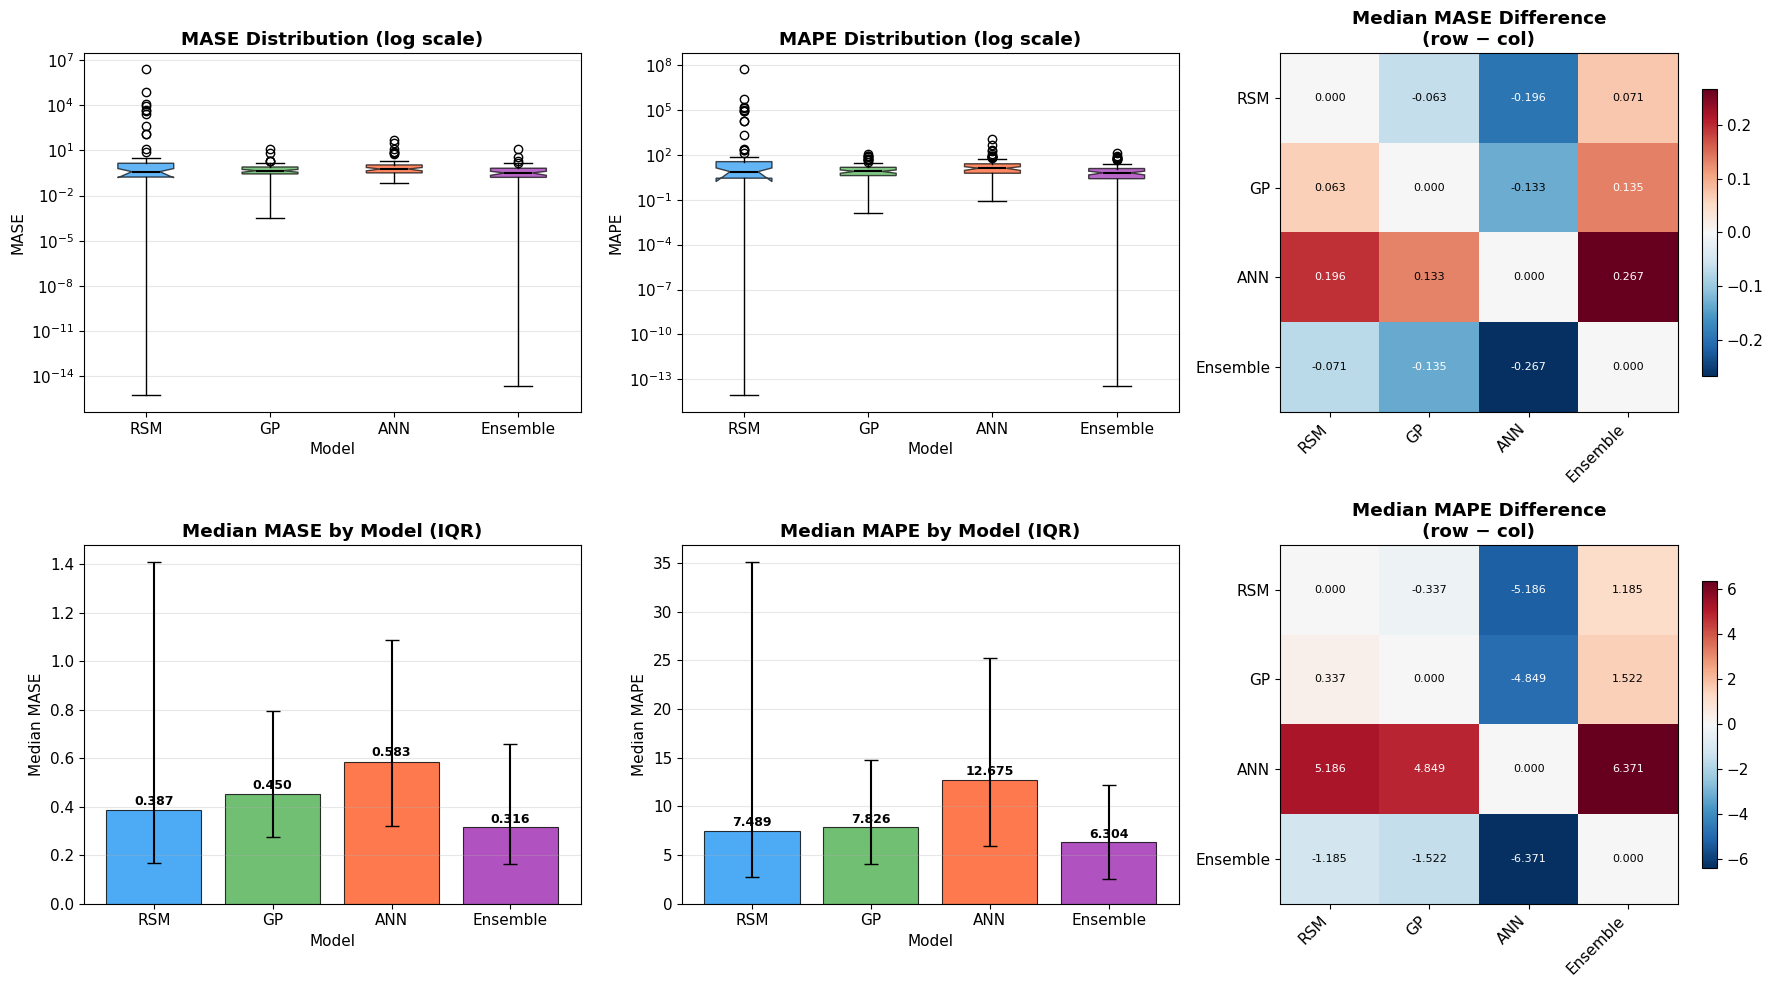

In [6]:
# ── 3. Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, metric in enumerate(['MASE', 'MAPE']):
    data_groups = [met_df.loc[met_df['MODEL'] == m, metric].dropna().values for m in model_order]

    # (a) Box plot – log scale to handle outliers
    ax = axes[0, col_idx]
    bp = ax.boxplot(data_groups, tick_labels=model_order, patch_artist=True, notch=True,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_yscale('log')
    ax.set_title(f'{metric} Distribution (log scale)', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)

    # (b) Median bar chart (robust to outliers)
    ax = axes[1, col_idx]
    medians = [np.median(g) for g in data_groups]
    q25 = [np.percentile(g, 25) for g in data_groups]
    q75 = [np.percentile(g, 75) for g in data_groups]
    yerr_low = [med - q for med, q in zip(medians, q25)]
    yerr_high = [q - med for med, q in zip(medians, q75)]
    bars = ax.bar(model_order, medians, yerr=[yerr_low, yerr_high], capsize=5,
                  color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
    ax.set_title(f'Median {metric} by Model (IQR)', fontweight='bold')
    ax.set_ylabel(f'Median {metric}')
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)
    for bar, m in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# (c) Pairwise mean-difference heatmaps
for row_idx, metric in enumerate(['MASE', 'MAPE']):
    ax = axes[row_idx, 2]
    n = len(model_order)
    diff_mat = np.zeros((n, n))
    for i, m1 in enumerate(model_order):
        for j, m2 in enumerate(model_order):
            diff_mat[i, j] = (met_df.loc[met_df['MODEL'] == m1, metric].median()
                              - met_df.loc[met_df['MODEL'] == m2, metric].median())
    im = ax.imshow(diff_mat, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(n)); ax.set_xticklabels(model_order, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(model_order)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{diff_mat[i,j]:.3f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(diff_mat[i,j]) > np.max(np.abs(diff_mat))*0.5 else 'black')
    ax.set_title(f'Median {metric} Difference\n(row − col)', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
# plt.savefig('model_MASE_MAPE_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# print("\nPlot saved as 'model_MASE_MAPE_comparison.png'")

Rows: 300 original → 237 after removing 63 outlier rows

Per-model counts (original → cleaned):
         RSM: 75 → 53  (removed 22)
          GP: 75 → 63  (removed 12)
         ANN: 75 → 58  (removed 17)
    Ensemble: 75 → 63  (removed 12)


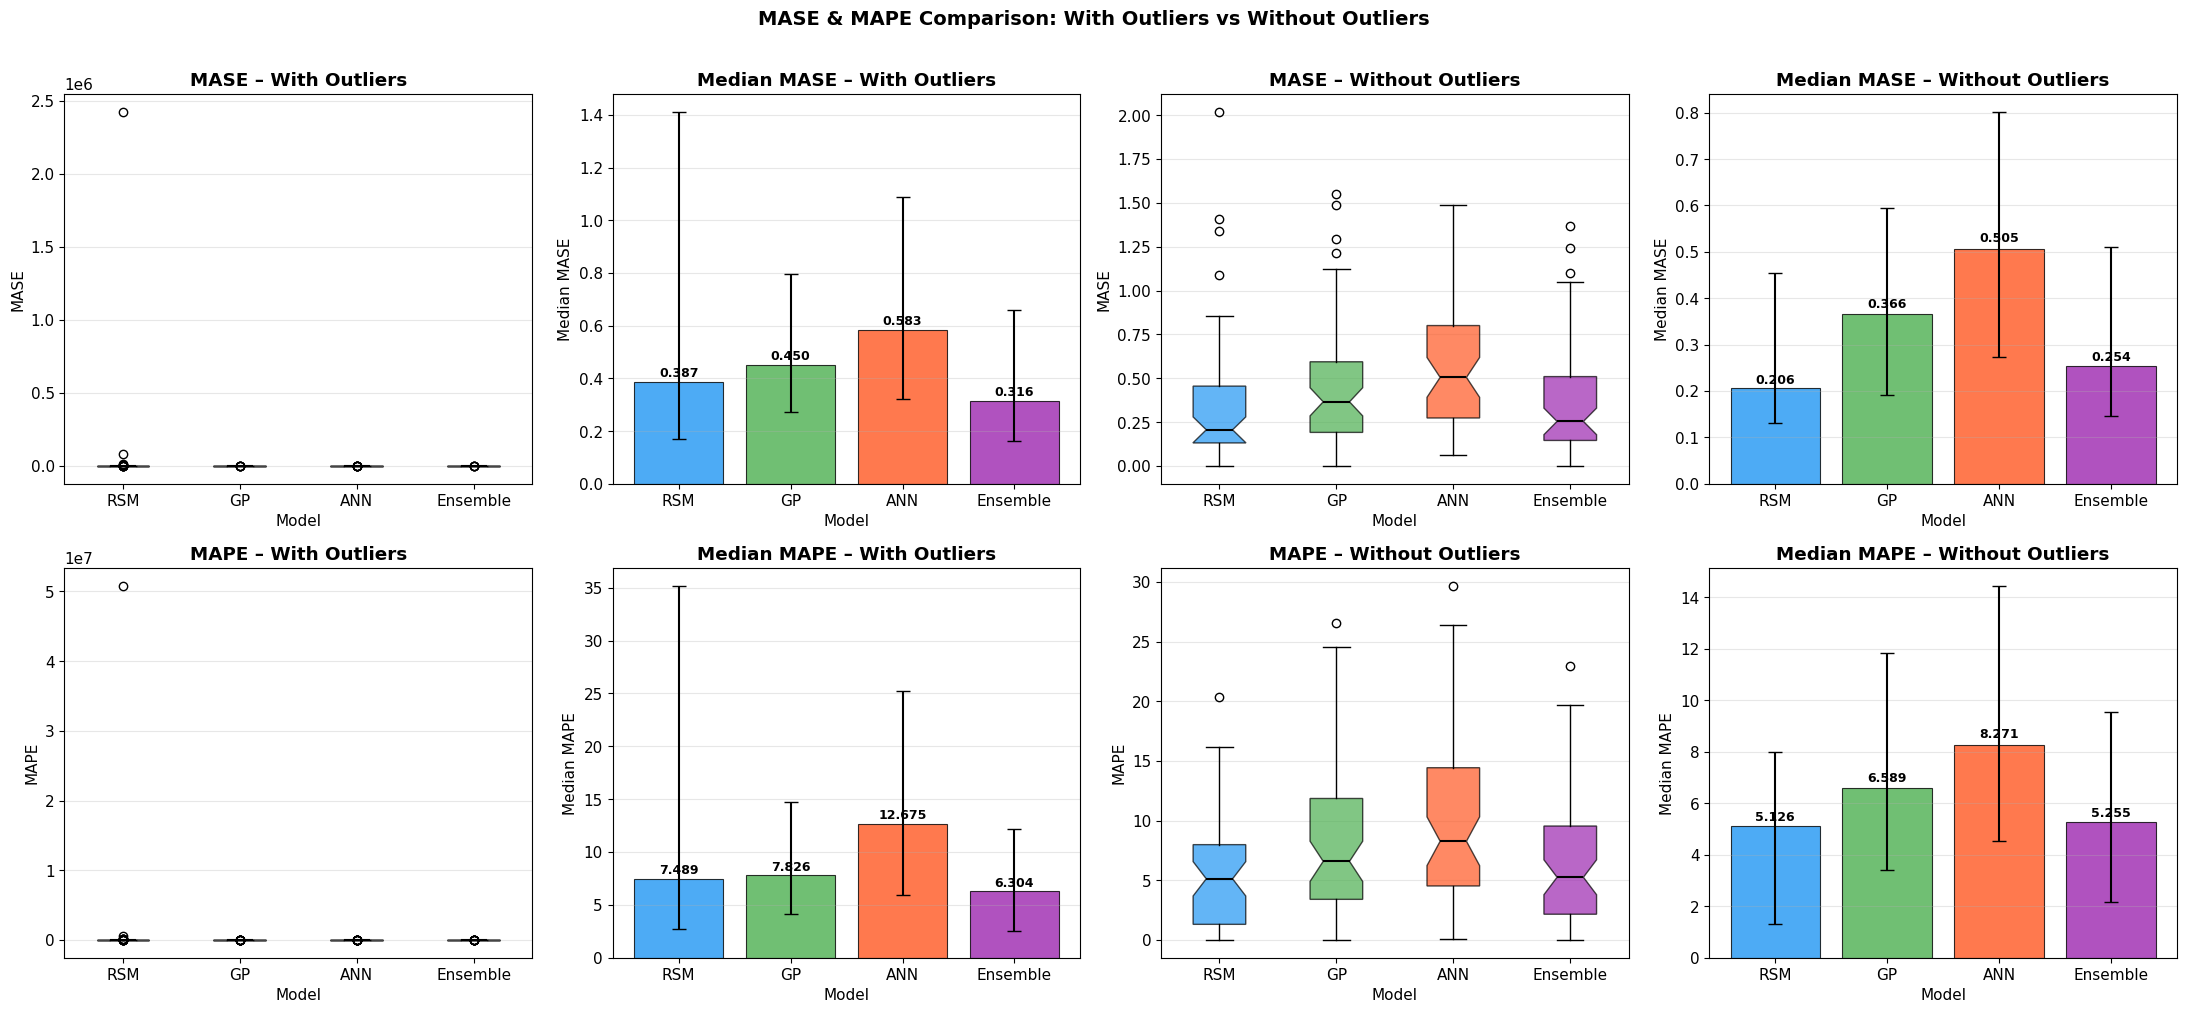


COMPARISON TABLE: Median (Mean ± Std) with and without outliers
Model      Metric                  With Outliers                Without Outliers    Δ Median
------------------------------------------------------------------------------------------
RSM        MASE   med=   0.387 (μ= 36781.419 ± 291901.887)  med=   0.206 (μ=   0.362 ±    0.403)      +0.181
GP         MASE   med=   0.450 (μ=     0.813 ±      1.694)  med=   0.366 (μ=   0.458 ±    0.364)      +0.084
ANN        MASE   med=   0.583 (μ=     2.383 ±      7.409)  med=   0.505 (μ=   0.562 ±    0.357)      +0.078
Ensemble   MASE   med=   0.316 (μ=     0.694 ±      1.612)  med=   0.254 (μ=   0.362 ±    0.316)      +0.061

RSM        MAPE   med=   7.489 (μ=692358.249 ± 5867185.416)  med=   5.126 (μ=   5.285 ±    4.459)      +2.363
GP         MAPE   med=   7.826 (μ=    16.686 ±     23.660)  med=   6.589 (μ=   7.963 ±    6.145)      +1.237
ANN        MAPE   med=  12.675 (μ=    45.171 ±    139.784)  med=   8.271 (μ=  10.523 ±    7.433

In [ ]:
# ── 4. With vs Without Outliers Comparison ──────────────────────────────
# Remove outliers using IQR method per MODEL per metric
def remove_outliers_iqr(df, group_col, metric_col):
    """Remove rows where metric is outside 1.5*IQR per group."""
    mask = pd.Series(True, index=df.index)
    for grp in df[group_col].unique():
        idx = df[group_col] == grp
        q1 = df.loc[idx, metric_col].quantile(0.25)
        q3 = df.loc[idx, metric_col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask &= ~(idx & ((df[metric_col] < lower) | (df[metric_col] > upper)))
    return df[mask]

# Build cleaned df (outliers removed for both MASE and MAPE simultaneously)
clean_df = met_df.copy()
for m in ['MASE', 'MAPE']:
    clean_df = remove_outliers_iqr(clean_df, 'MODEL', m)

n_removed = len(met_df) - len(clean_df)
print(f"Rows: {len(met_df)} original → {len(clean_df)} after removing {n_removed} outlier rows")
print(f"\nPer-model counts (original → cleaned):")
for m in model_order:
    n_orig = (met_df['MODEL'] == m).sum()
    n_clean = (clean_df['MODEL'] == m).sum()
    print(f"  {m:>10s}: {n_orig} → {n_clean}  (removed {n_orig - n_clean})")

# ── Side-by-side comparison plots ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('MASE & MAPE Comparison: With Outliers vs Without Outliers', fontsize=14, fontweight='bold', y=1.01)

datasets = [('With Outliers', met_df), ('Without Outliers', clean_df)]

for row_idx, metric in enumerate(['MASE', 'MAPE']):
    for ds_idx, (label, data) in enumerate(datasets):
        # Box plots
        ax = axes[row_idx, ds_idx * 2]
        data_groups = [data.loc[data['MODEL'] == m, metric].dropna().values for m in model_order]
        bp = ax.boxplot(data_groups, tick_labels=model_order, patch_artist=True, notch=True,
                        medianprops=dict(color='black', linewidth=1.5))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(f'{metric} – {label}', fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_xlabel('Model')
        ax.grid(axis='y', alpha=0.3)

        # Bar charts (median + IQR)
        ax2 = axes[row_idx, ds_idx * 2 + 1]
        medians = [np.median(g) for g in data_groups]
        q25 = [np.percentile(g, 25) for g in data_groups]
        q75 = [np.percentile(g, 75) for g in data_groups]
        yerr_low = [med - q for med, q in zip(medians, q25)]
        yerr_high = [q - med for med, q in zip(medians, q75)]
        bars = ax2.bar(model_order, medians, yerr=[yerr_low, yerr_high], capsize=5,
                       color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
        ax2.set_title(f'Median {metric} – {label}', fontweight='bold')
        ax2.set_ylabel(f'Median {metric}')
        ax2.set_xlabel('Model')
        ax2.grid(axis='y', alpha=0.3)
        for bar, mv in zip(bars, medians):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                     f'{mv:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Summary table: with vs without outliers ─────────────────────────
print("\n" + "="*80)
print("COMPARISON TABLE: Median (Mean ± Std) with and without outliers")
print("="*80)
print(f"{'Model':<10} {'Metric':<6} {'With Outliers':>30}  {'Without Outliers':>30}  {'Δ Median':>10}")
print("-"*90)
for metric in ['MASE', 'MAPE']:
    for m in model_order:
        orig = met_df.loc[met_df['MODEL'] == m, metric]
        cln = clean_df.loc[clean_df['MODEL'] == m, metric]
        delta = orig.median() - cln.median()
        print(f"{m:<10} {metric:<6} "
              f"med={orig.median():8.3f} (μ={orig.mean():10.3f} ± {orig.std():10.3f})  "
              f"med={cln.median():8.3f} (μ={cln.mean():8.3f} ± {cln.std():8.3f})  "
              f"{delta:+10.3f}")
    print()

# ── Pairwise Wilcoxon tests WITHOUT outliers ────────────────────────
print("=== Pairwise Wilcoxon Rank-Sum Tests (WITHOUT outliers) ===")
for metric in ['MASE', 'MAPE']:
    print(f"\n--- {metric} ---")
    for m1, m2 in combinations(models, 2):
        g1 = clean_df.loc[clean_df['MODEL'] == m1, metric].dropna()
        g2 = clean_df.loc[clean_df['MODEL'] == m2, metric].dropna()
        stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p={pval:.4e}  {sig}")

In [9]:
# ── 6. ANOVA & Kruskal-Wallis (WITHOUT outliers) ────────────────────────
from scipy.stats import f_oneway, kruskal, levene, shapiro

for metric in ['MASE', 'MAPE']:
    groups = [clean_df.loc[clean_df['MODEL'] == m, metric].dropna().values for m in model_order]

    print(f"\n{'='*60}")
    print(f"  {metric}  (outliers removed)")
    print(f"{'='*60}")

    # ── Assumption checks ───────────────────────────────────────
    print("\nShapiro-Wilk normality test:")
    for m, g in zip(model_order, groups):
        if len(g) >= 3:
            w, p = shapiro(g)
            print(f"  {m:>10s}:  W={w:.4f}  p={p:.4e}  {'normal' if p > 0.05 else 'non-normal'}")

    lev_stat, lev_p = levene(*groups)
    print(f"\nLevene's test (equal variances):  stat={lev_stat:.4f}  p={lev_p:.4e}  "
          f"{'equal' if lev_p > 0.05 else 'unequal'}")

    # ── One-way ANOVA ───────────────────────────────────────────
    f_stat, anova_p = f_oneway(*groups)
    print(f"\nOne-way ANOVA:  F={f_stat:.4f}  p={anova_p:.4e}  "
          f"{'***' if anova_p < 0.001 else '**' if anova_p < 0.01 else '*' if anova_p < 0.05 else 'ns'}")

    # ── Kruskal-Wallis (non-parametric alternative) ─────────────
    h_stat, kw_p = kruskal(*groups)
    print(f"Kruskal-Wallis: H={h_stat:.4f}  p={kw_p:.4e}  "
          f"{'***' if kw_p < 0.001 else '**' if kw_p < 0.01 else '*' if kw_p < 0.05 else 'ns'}")

    # ── Post-hoc Dunn's test (if Kruskal-Wallis significant) ────
    if kw_p < 0.05:
        try:
            import scikit_posthocs as sp
            dunn = sp.posthoc_dunn(clean_df, val_col=metric, group_col='MODEL', p_adjust='bonferroni')
            print(f"\nDunn's post-hoc test (Bonferroni-adjusted p-values):")
            print(dunn.to_string())
        except ImportError:
            print("\n  (Install scikit-posthocs for Dunn's post-hoc test: pip install scikit-posthocs)")
            from itertools import combinations
            n_comp = len(list(combinations(model_order, 2)))
            print(f"\n  Pairwise Mann-Whitney U with Bonferroni correction ({n_comp} comparisons):")
            for m1, m2 in combinations(model_order, 2):
                g1 = clean_df.loc[clean_df['MODEL'] == m1, metric].dropna()
                g2 = clean_df.loc[clean_df['MODEL'] == m2, metric].dropna()
                stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                adj_p = min(pval * n_comp, 1.0)
                sig = '***' if adj_p < 0.001 else '**' if adj_p < 0.01 else '*' if adj_p < 0.05 else 'ns'
                print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p_adj={adj_p:.4e}  {sig}")


  MASE  (outliers removed)

Shapiro-Wilk normality test:
         RSM:  W=0.7336  p=5.4806e-08  non-normal
          GP:  W=0.9004  p=1.0597e-04  non-normal
         ANN:  W=0.9371  p=7.7498e-03  non-normal
    Ensemble:  W=0.8477  p=4.2113e-06  non-normal

Levene's test (equal variances):  stat=0.4953  p=6.8595e-01  equal

One-way ANOVA:  F=3.7148  p=1.2328e-02  *
Kruskal-Wallis: H=17.3947  p=5.8620e-04  ***

  (Install scikit-posthocs for Dunn's post-hoc test: pip install scikit-posthocs)

  Pairwise Mann-Whitney U with Bonferroni correction (6 comparisons):
           RSM vs GP          U=    1138.0  p_adj=2.1096e-01  ns
           RSM vs ANN         U=     735.0  p_adj=1.5832e-03  **
           RSM vs Ensemble    U=    1281.0  p_adj=1.0000e+00  ns
            GP vs ANN         U=    1336.0  p_adj=5.1290e-01  ns
            GP vs Ensemble    U=    2089.0  p_adj=5.2337e-01  ns
           ANN vs Ensemble    U=    2074.0  p_adj=4.5442e-03  **

  MAPE  (outliers removed)

Shapiro-Wilk 

In [11]:
# ── 7. Model comparison by DESIGN_TYPE (outliers removed) ───────────────
from scipy.stats import f_oneway, kruskal, levene, shapiro
from itertools import combinations

design_types = sorted(clean_df['DESIGN_TYPE'].dropna().unique())
print(f"Design types found: {design_types}\n")

for dt in design_types:
    sub = clean_df[clean_df['DESIGN_TYPE'] == dt]
    print(f"\n{'#'*70}")
    print(f"  DESIGN TYPE: {dt}   (n = {len(sub)})")
    print(f"{'#'*70}")

    for metric in ['MASE', 'MAPE']:
        groups = [sub.loc[sub['MODEL'] == m, metric].dropna().values for m in model_order]
        sizes = [len(g) for g in groups]

        print(f"\n{'='*60}")
        print(f"  {metric}  |  {dt}")
        print(f"{'='*60}")
        print(f"  Group sizes: {dict(zip(model_order, sizes))}")

        # Skip if any group has fewer than 3 observations
        if any(s < 3 for s in sizes):
            print("  ⚠ Skipping — at least one model has < 3 observations for this design type.")
            continue

        # ── Descriptive stats ───────────────────────────────────
        print(f"\n  {'Model':<10} {'n':>4} {'Median':>10} {'Mean':>10} {'Std':>10}")
        print(f"  {'-'*48}")
        for m, g in zip(model_order, groups):
            print(f"  {m:<10} {len(g):>4} {np.median(g):>10.4f} {np.mean(g):>10.4f} {np.std(g, ddof=1):>10.4f}")

        # ── Shapiro-Wilk normality ──────────────────────────────
        print("\n  Shapiro-Wilk normality:")
        for m, g in zip(model_order, groups):
            w, p = shapiro(g)
            print(f"    {m:>10s}:  W={w:.4f}  p={p:.4e}  {'normal' if p > 0.05 else 'non-normal'}")

        # ── Levene's test ───────────────────────────────────────
        lev_stat, lev_p = levene(*groups)
        print(f"\n  Levene's test:  stat={lev_stat:.4f}  p={lev_p:.4e}  "
              f"{'equal' if lev_p > 0.05 else 'unequal'}")

        # ── One-way ANOVA ───────────────────────────────────────
        f_stat, anova_p = f_oneway(*groups)
        sig = '***' if anova_p < 0.001 else '**' if anova_p < 0.01 else '*' if anova_p < 0.05 else 'ns'
        print(f"\n  One-way ANOVA:  F={f_stat:.4f}  p={anova_p:.4e}  {sig}")

        # ── Kruskal-Wallis ──────────────────────────────────────
        h_stat, kw_p = kruskal(*groups)
        sig_kw = '***' if kw_p < 0.001 else '**' if kw_p < 0.01 else '*' if kw_p < 0.05 else 'ns'
        print(f"  Kruskal-Wallis: H={h_stat:.4f}  p={kw_p:.4e}  {sig_kw}")

        # ── Pairwise Wilcoxon Rank-Sum Tests ────────────────────
        print(f"\n  Pairwise Wilcoxon Rank-Sum Tests:")
        for m1, m2 in combinations(model_order, 2):
            g1 = sub.loc[sub['MODEL'] == m1, metric].dropna()
            g2 = sub.loc[sub['MODEL'] == m2, metric].dropna()
            stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            sig_w = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p={pval:.4e}  {sig_w}")

        # ── Mann-Whitney U with Bonferroni correction ───────────
        n_comp = len(list(combinations(model_order, 2)))
        print(f"\n  Mann-Whitney U with Bonferroni correction ({n_comp} comparisons):")
        for m1, m2 in combinations(model_order, 2):
            g1 = sub.loc[sub['MODEL'] == m1, metric].dropna()
            g2 = sub.loc[sub['MODEL'] == m2, metric].dropna()
            stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            adj_p = min(pval * n_comp, 1.0)
            s = '***' if adj_p < 0.001 else '**' if adj_p < 0.01 else '*' if adj_p < 0.05 else 'ns'
            print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p_adj={adj_p:.4e}  {s}")

        # ── Dunn's post-hoc (if Kruskal-Wallis significant) ─────
        if kw_p < 0.05:
            try:
                import scikit_posthocs as sp
                dunn = sp.posthoc_dunn(sub, val_col=metric, group_col='MODEL', p_adjust='bonferroni')
                print(f"\n  Dunn's post-hoc (Bonferroni):")
                for line in dunn.to_string().split('\n'):
                    print(f"    {line}")
            except ImportError:
                pass

Design types found: ['BBD', 'CCD', 'CCFD', 'CCRD', 'DSD', 'FD', 'TAG']


######################################################################
  DESIGN TYPE: BBD   (n = 68)
######################################################################

  MASE  |  BBD
  Group sizes: {'RSM': 16, 'GP': 18, 'ANN': 17, 'Ensemble': 17}

  Model         n     Median       Mean        Std
  ------------------------------------------------
  RSM          16     0.1927     0.2680     0.2208
  GP           18     0.3338     0.4755     0.3752
  ANN          17     0.5210     0.5223     0.2837
  Ensemble     17     0.1614     0.3168     0.3392

  Shapiro-Wilk normality:
           RSM:  W=0.8713  p=2.8509e-02  non-normal
            GP:  W=0.8071  p=1.9178e-03  non-normal
           ANN:  W=0.9654  p=7.3445e-01  normal
      Ensemble:  W=0.7859  p=1.3071e-03  non-normal

  Levene's test:  stat=0.4084  p=7.4751e-01  equal

  One-way ANOVA:  F=2.5696  p=6.1958e-02  ns
  Kruskal-Wallis: H=10.1165  p=1.7601e-